### Load 2D data file in SASView

2D fit with cylinder model
* no structure factor
* two angular distributions along $\delta_1$ and $\delta_2$

TO DO next:
* add a rectangular region to mask the structure factor peaks
* compare with 1D fiting of the same image
* compare with azimuthal fit profiles
* add calculation of S the order parameter from the angular distribution

developpement in SASView:
* go for qx, qy, qz data
* code a cylinder model for uniaxial distribution: angular distribution along $\delta_1$ + uniform distribution along $\delta_3$
* add Maier-Saupe distribution in the weights.py file

run using global (Python 3.12.10) on PC fixe 

import all the packages

In [1]:
import maier_saupe

In [2]:
import numpy as np

# import sasmodels
import sasmodels
import sasmodels.core
import sasmodels.data
import sasmodels.bumps_model

import sasdata

from sasdata.dataloader.loader import Loader
from sasmodels.data import load_data
#from sas import sascalc.dataloader

from sasmodels.data import plot_theory

import bumps
import bumps.fitters
import bumps.names
import bumps.fitproblem

import os



In [3]:

"""
import matplotlib.pyplot and set custom default settings for plots
"""
%matplotlib inline
import matplotlib_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')


import matplotlib.pyplot as plt
#from IPython.display import set_matplotlib_formats
#set_matplotlib_formats('svg')

plt.rc('font', size=14) # default fontsize
plt.rc('axes', titlesize=16)
plt.rc('axes', labelsize=16)
plt.rc('xtick', labelsize=14)
plt.rc('ytick', labelsize=14)
plt.rc('legend', fontsize=14)
plt.rc('legend', title_fontsize=14)
plt.rc('figure', titlesize=18)
plt.rc("figure", figsize=(5,5))
plt.rc("lines", linewidth=3)

#import tol_colors as tc # colorblind safe color palettes

# use colorblind safe colors:
#plt.rc('axes', prop_cycle=plt.cycler('color', list(tc.tol_cset('muted'))))
#try:
#    plt.cm.register_cmap('tc_iridescent', tc.tol_cmap('iridescent'))
#except:
#    pass

#plt.rc('image', cmap='tc_iridescent')

#plt.rc('image', cmap='rainbow')
plt.rc('image', cmap='jet')



### file selection

nematic phase under E field SWING data
* .dat file obtained from SAXSProcessor by Nicolas

In [4]:
filename="./images/Nematic/sasview_exports/5V_194.dat"


### data loader method

In [5]:

data2d=sasmodels.data.load_data(filename)

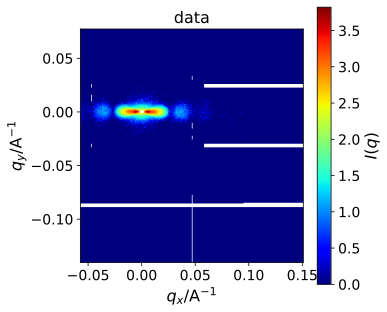

In [6]:
sasmodels.data.plot_data(data2d)

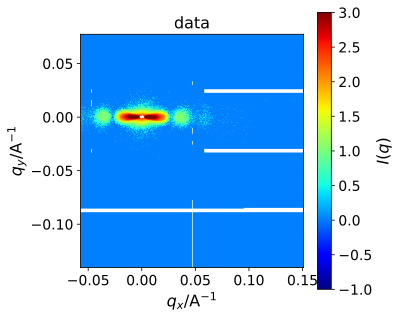

In [7]:
sasmodels.data.plot_data(data2d,view='log',limits=[0.1,1000])

#limits in intensity.

* store in I_all, qx_all and qy_all

In [8]:
I_all=data2d.data
#all intensity value sin data2d...
qx_all=data2d.qx_data
qy_all=data2d.qy_data

In [9]:
#I_error=data2d.errors

* rebuilt a data set

In [10]:
data_all = sasmodels.data.Data2D(x=qx_all, y=qy_all, z=I_all,dx=None,dy=None,dz=None)

#dx, dy, dz None, no errors

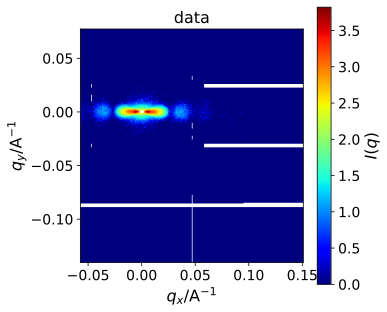

In [11]:
sasmodels.data.plot_data(data_all)

### reduce the number of data points before fiting

TO DO: add a circle in the middle to exclude the beamstop region

* create a numpy array
* ROI with qmax_x and qmax_y
* add a I_min value to avoir data points equal to zero  ... 
* errors proportionnal to intensity values (usually 10%)
* USE slicing=1 for a nice output with all data points in the ROI

65924
3297


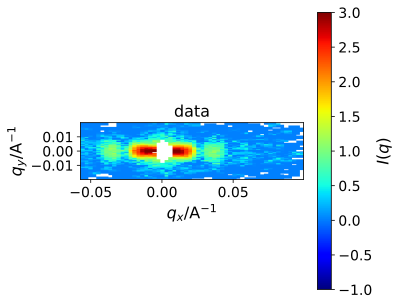

In [12]:
number_all=I_all.shape[0]

data_np=[]

# minvalue for data2d
I_min=0.0001

#error coefficient I*coefficient 
error_coeff=0.05
#error_min=0.000000

#ROI
qmax_x=0.1
qmax_y=0.02

#exclude a circle around the beamstop

q_center=0.01
#mask center radius...

#rectangular mask:

qmax_x_R=0.015
qmax_y_R=0.005

for i in range(number_all):
    if I_all[i]> I_min and (-qmax_x)<qx_all[i]<qmax_x and (-qmax_y)<qy_all[i]<qmax_y and (qx_all[i]**2+qy_all[i]**2)>q_center**2 :
#    print(I_all[i])
        data_np.append([qx_all[i],qy_all[i],I_all[i],error_coeff*I_all[i]])

data_np=np.array(data_np) 

size=data_np.shape[0]


print(size)

#slicing equal to one for keeping all data points in the ROI
slicing=20

data_reduced_ROI = sasmodels.data.Data2D(x=data_np[0:size:slicing,0], 
                                     y=data_np[0:size:slicing,1], 
                                     z=data_np[0:size:slicing,2],
                                     dx=None,dy=None,
                                     dz=data_np[0:size:slicing,3])

sasmodels.data.plot_data(data_reduced_ROI,view="log",limits=[0.1,1000])
size_reduced=data_np[0:size:slicing,0].shape[0]
print(size_reduced)

In [13]:
print(data_reduced_ROI.data)

[1. 1. 2. ... 2. 2. 1.]


### fiting of the reduced set of data points in the image

* choice of the elliptical cylinder model 
* can be replaced by any other model !

In [19]:
kernel = sasmodels.core.load_model("elliptical_cylinder")
params = {} # default parameters for now, parameters...
model = sasmodels.bumps_model.Model(kernel, **params)
experiment = sasmodels.bumps_model.Experiment(data=data_reduced_ROI, model=model)

In [21]:
model.radius_minor.value

20.0

In [22]:
model.axis_ratio.value

1.5

first manual adjustement of different parameters

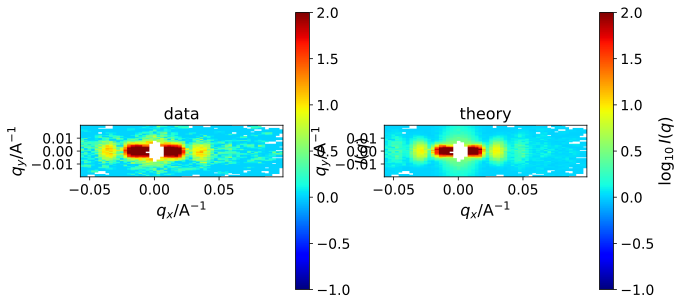

In [36]:
params = {
    "phi": 90, "theta": 90, "psi": 0,

#    "psi_pd_type": 'gaussian', #polydispersity function
#    "psi_pd": 10, #polydispersity
#    "psi_pd_n": 40, #number of steps in polydispersity
#    "psi_pd_nsigma": 3, #range of polydispersity

    "phi_pd_type": 'gaussian', #polydispersity function
    "phi_pd": 8, #polydispersity
    "phi_pd_n": 40, #number of steps in polydispersity
    "phi_pd_nsigma": 3, #range of polydispersity

    "theta_pd_type": 'gaussian', #polydispersity function
   "theta_pd": 8, #polydispersity
    "theta_pd_n": 40, #number of steps in polydispersity
   "theta_pd_nsigma": 3, #range of polydispersity

    "radius_minor": 170,#radius of the NRs
    "axis_ratio":1, # ratio foe the elliptical cylinder cross section
    "radius_minor_pd_type": 'gaussian', #number of steps in polydispersity
    "radius_minor_pd": 0.05, #polydispersity
    "radius_minor_pd_n": 8, #number of steps in polydispersity
    "radius_minor_pd_nsigma": 4, #range of polydispersity
    "length":10000,
    "background": 1,
    "scale": 0.01
}
model = sasmodels.bumps_model.Model(model=kernel, **params)
experiment = sasmodels.bumps_model.Experiment(data=data_reduced_ROI, model=model)

plt.figure(figsize=(10,5))

#experiment.plot()

plot_theory(data_reduced_ROI,experiment.theory(),view="log",limits=[0.1,100])

* choice of the initial values for parameters
* choice of the fiting parameters with their fiting range

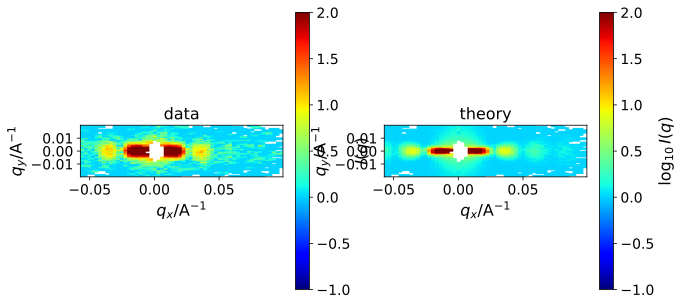

In [15]:
params = {
    "phi": 90, 
    "theta": 90,

    "phi_pd_type": 'gaussian', #polydispersity function
    "phi_pd": 4, #polydispersity
    "phi_pd_n": 40, #number of steps in polydispersity
    "phi_pd_nsigma": 4, #range of polydispersity   

    "theta_pd_type": 'gaussian', #polydispersity function
    "theta_pd": 4, #polydispersity
    "theta_pd_n": 40, #number of steps in polydispersity
    "theta_pd_nsigma": 4, #range of polydispersity  

#    "theta_pd_type": 'uniform', #polydispersity function
#    "theta_pd": 360, #polydispersity

    "radius": 140,
    "radius_pd_type": 'gaussian', #number of steps in polydispersity
    "radius_pd": 0.036, #polydispersity
    "radius_pd_n": 8, #number of steps in polydispersity
    "radius_pd_nsigma": 4, #range of polydispersity

    "length":10000,

    "background": 1,
    "scale": 0.008
}

model = sasmodels.bumps_model.Model(model=kernel, **params)

#list of the fiting parameters with their fiting range
model.scale.range(0.005,0.1)
model.background.range(0.01,10)

#model.phi.range(70,120)
model.theta.range(70,150)

#model.phi_pd.range(5, 10)
#model.theta_pd.range(5, 10)

model.length.range(5000,20000)

model.radius.range(100,200)
#model.radius_pd.range(0.,0.1)

experiment = sasmodels.bumps_model.Experiment(data=data_reduced_ROI, model=model)

plt.figure(figsize=(10,5))
#experiment.plot()
plot_theory(data_reduced_ROI,experiment.theory(),view="log",limits=[0.1,100])

* creation of the fit `problem` 
* `problem` is generated by FitProblem in bump module
* RUN the fit problem

In [16]:
problem = bumps.fitproblem.FitProblem(experiment)

results = bumps.fitters.fit(problem, method='lm',steps=20, ftol=1.5e-08, xtol=1.5e-08, verbose=True)

plt.figure(figsize=(10, 5))
experiment.plot()

step 1 cost 97.6327(18)
                              background |.........          1 in [0.01, 10]
                                  length ...|......      10000 in [5000, 20000]
                                  radius ...|......        140 in [100, 200]
                                   scale |.........      0.008 in [0.005, 0.1]
                                   theta ..|.......         90 in [70, 150]
step 2 cost 97.2404(18)
step 3 cost 97.2299(18)
step 4 cost 97.2089(18)
step 5 cost 97.1678(18)
                              background |.........    1.00014 in [0.01, 10]
                                  length ...|......    9999.49 in [5000, 20000]
                                  radius ....|.....    140.014 in [100, 200]
                                   scale |......... 0.00803333 in [0.005, 0.1]
                                   theta ...|......    96.2394 in [70, 150]
step 6 cost 97.0887(18)
step 7 cost 96.9420(18)


KeyboardInterrupt: 

In [ ]:
print(problem.model_parameters())

{'models': [{'scale': Parameter(scale), 'background': Parameter(background), 'sld': Parameter(sld), 'sld_solvent': Parameter(sld_solvent), 'radius': Parameter(radius), 'radius_pd': Parameter(radius_pd), 'radius_pd_n': Parameter(radius_pd_n), 'radius_pd_nsigma': Parameter(radius_pd_nsigma), 'length': Parameter(length), 'length_pd': Parameter(length_pd), 'length_pd_n': Parameter(length_pd_n), 'length_pd_nsigma': Parameter(length_pd_nsigma), 'theta': Parameter(theta), 'theta_pd': Parameter(theta_pd), 'theta_pd_n': Parameter(theta_pd_n), 'theta_pd_nsigma': Parameter(theta_pd_nsigma), 'phi': Parameter(phi), 'phi_pd': Parameter(phi_pd), 'phi_pd_n': Parameter(phi_pd_n), 'phi_pd_nsigma': Parameter(phi_pd_nsigma), 'up_frac_i': Parameter(up_frac_i), 'up_frac_f': Parameter(up_frac_f), 'up_theta': Parameter(up_theta), 'up_phi': Parameter(up_phi), 'sld_M0': Parameter(sld_M0), 'sld_mtheta': Parameter(sld_mtheta), 'sld_mphi': Parameter(sld_mphi), 'sld_solvent_M0': Parameter(sld_solvent_M0), 'sld_solv

In [ ]:
print(problem.summarize())

                              background |.........   0.826055 in [0.01, 10]
                                  length ...|......    10704.7 in [5000, 20000]
                                  radius ....|.....    140.859 in [100, 200]
                                   scale |......... 0.00678973 in [0.005, 0.1]
                                   theta .........|    145.949 in [70, 150]


In [ ]:
print(problem.chisq())

96.51497479965911


### plot after fiting

labels of the fiting parameters

In [46]:
problem.labels()

['background', 'radius', 'radius_pd', 'scale']

fited values of the parameters

In [47]:
results.x

array([9.66380683e-01, 1.40755758e+02, 3.59958679e-02, 9.61595700e-03])

error of the fited values

In [48]:
results.dx

array([1.48332945e-03, 3.74000826e-02, 4.55297285e-04, 2.77114003e-05])

In [49]:
model.phi.value

90.0

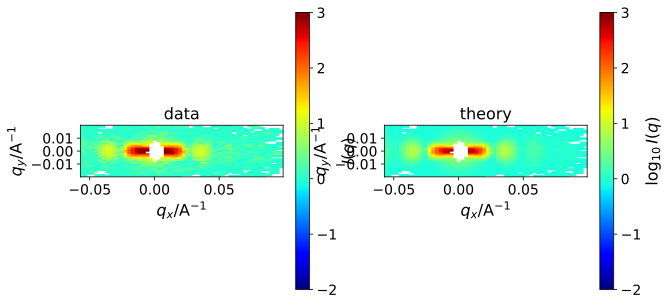

In [62]:
params = {
    "phi": model.phi.value, 
    "theta": model.theta.value,

    "phi_pd_type": 'gaussian', #polydispersity function
    "phi_pd": model.phi_pd.value, #polydispersity
    "phi_pd_n": model.phi_pd_n, #number of steps in polydispersity
    "phi_pd_nsigma": model.phi_pd_nsigma, #range of polydispersity  

    "radius": model.radius.value,
    "radius_pd_type": 'gaussian', #number of steps in polydispersity
    "radius_pd": model.radius_pd, #polydispersity
    "radius_pd_n": model.radius_pd_n, #number of steps in polydispersity
    "radius_pd_nsigma": model.radius_pd_nsigma, #range of polydispersity
    "length":model.length.value,
    "background": model.background.value,
    "scale": model.scale.value
}

model = sasmodels.bumps_model.Model(model=kernel, **params)
experiment = sasmodels.bumps_model.Experiment(data=data_reduced_ROI, model=model)

plt.figure(figsize=(10,5))
#experiment.plot()
plot_theory(data_reduced_ROI,experiment.theory(),view="log",limits=[0.01,1000])



In [53]:
problem.fitness.theory()

c:\Users\Administrateur\AppData\Local\Programs\Python\Python312\Lib\site-packages\bumps\fitproblem.py:305: UserWarning: Deprecated: use of problem.fitness will be removed at some point
  warnings.warn("Deprecated: use of problem.fitness will be removed at some point")


array([0.96738111, 1.19712936, 1.19806934, ..., 1.19396565, 1.19703157,
       0.96677056], shape=(3297,))

### cylinder model and orientation distribution:
* [cylinder model and angles](https://www.sasview.org/docs/user/models/cylinder.html)
* Angles θ and ϕ orient the cylinder relative to the beam line coordinates, where the beam is along the z axis. Rotation θ, initially in the xz plane, is carried out first, then rotation ϕ about the z axis. 
* Orientation distributions are described as rotations about two perpendicular axes δ1 and δ2 in the frame of the cylinder itself, which when θ=ϕ=0 are parallel to the Y and X axes.
* <img src="https://www.sasview.org/docs/_images/cylinder_angle_definition.png">
* <img src="https://www.sasview.org/docs/_images/cylinder_angle_projection.png">

### bumps for fiting
The default optimizer for the bumps fit is the Levenberg-Marquardt method, but there are many available as described in greater detail in the Bumps [documentation](https://bumps.readthedocs.io/en/latest/guide/optimizer.html) with additional fitting options.

For Levenberg-Marquardt, the steps, f(x) tolerance and x tolerance from the GUI options can be set with the `steps`, `ftol` and `xtol` arguments in the `fit` method.

<img src="https://bumps.readthedocs.io/en/latest/_images/fit-lm.png">

*Image source: https://bumps.readthedocs.io/en/latest/guide/optimizer.html*

### Explanation of the polydispersity parameters

The polydispersity is set using a special set of \*\_pd\_\* parameters:
* `*_pd*` is the width of the polydispersity and the exact definition will depend on the type of distribution specified; in this cause of a 'gaussian` distribution, it is defined as as $\frac{\sigma}{x_{mean}}$
* `*_pd_type*` defines the type of polydispersity distribution used
* `*_pd_n` corresponds to the the number of points in the distribution used by the calculation (Npts in the image below)
* `*_pd_nsigma` sets the range of the distribution sampled (Nsigmas in the image below)

For example, radius polydispersity could be defined by specifying **all four** of the pd parameters. With the default values, this would look like:
* `radius_pd = 0`
* `radius_pd_type = 'gaussian'`
* `radius_pd_n = 35`
* `radius_pd_nsigma = 3`

The available polydispersity distributions are defined in the SasView [documentation](https://www.sasview.org/docs/user/qtgui/Perspectives/Fitting/pd/polydispersity.html) but we can access them directly through the sasmodels `weights` module.

The 'gaussian' distribution is calculated by:

$$
f(x) = \frac{1}{Norm}\exp\left(-\frac{(x-x_{mean})^2}{2\sigma^2}\right)
$$

<img src=https://www.sasview.org/docs/_images/pd_gaussian.jpg>

*Image source: https://www.sasview.org/docs/user/qtgui/Perspectives/Fitting/pd/polydispersity.html*
